# 08 — Конфлюэнс фракталов: сила уровня = сколько фракталов слилось

Идея (user): взять ЧАСТЫЕ фракталы (k=2) и склеить по расстоянию N. Сила уровня =
число слитых фракталов → высокое разрешение по силе (у настоящего уровня десятки,
у шума мало). Раньше (k=10) сила была грубой (3-7). Вопрос: растёт ли edge / объёмный
след с СИЛОЙ — и переживает ли это matched-контроль расположения (урок nb06)?

Слияние = centroid-linkage (сливаем две ближайшие зоны пока зазор < N) — честная
версия «ближе N = один», без чейнинга single-linkage (баг nb01).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
rng = np.random.default_rng(0)
full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::4][:35]
START, END, TF = "2024-01-01", "2025-07-01", "1h"
TOL = 0.0015; CD = 6; LIFE = 720; W = 720; HLAB = 12; COST = 0.0015
NMERGE = 0.004   # merge fractals whose centroid gap < 0.4%
print(len(UNIV), "symbols")

35 symbols


In [2]:
def fractals(df, k=2):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i-k:i+k+1]; wL = l[i-k:i+k+1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def merge_centroid(prices, N):
    """1D centroid-linkage: repeatedly merge the closest-by-relative-gap adjacent
    centroids while gap < N. Returns [(price, strength)]. No single-link chaining."""
    if len(prices) == 0: return []
    cen = [[p, 1] for p in sorted(prices)]
    while len(cen) > 1:
        gaps = [(cen[i+1][0] - cen[i][0]) / cen[i][0] for i in range(len(cen) - 1)]
        j = int(np.argmin(gaps))
        if gaps[j] > N: break
        p0, n0 = cen[j]; p1, n1 = cen[j+1]
        cen[j] = [(p0*n0 + p1*n1) / (n0+n1), n0+n1]; del cen[j+1]
    return [(p, s) for p, s in cen]

def fractal_cluster_segments(df, k=2, R=24, life=LIFE, N=NMERGE):
    """Causal: every R bars, merge trailing confirmed fractals into zones with strength."""
    hi, lo = fractals(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); conf = []
    for i in np.where(hi)[0]: conf.append((i+k, h[i]))
    for i in np.where(lo)[0]: conf.append((i+k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2)); segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life)
        if m.sum() < 3: continue
        for price, strg in merge_centroid(conf[m, 1], N):
            if strg >= 3: segs.append((price, r, min(r+R, n), strg))
    return segs

307 fractals -> 30 zones (>=3), max strength 23
[saved] notebooks\levels\_out\08_fractal_zones.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/08_fractal_zones.png')

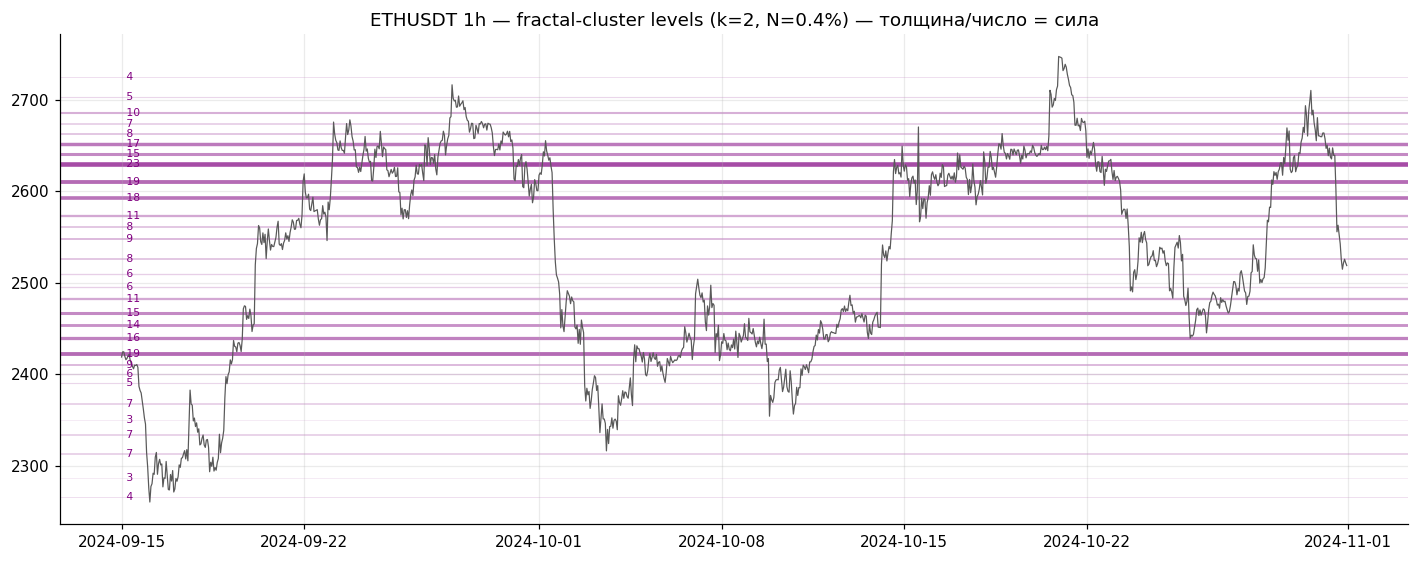

In [3]:
# visual + strength distribution on one symbol (as-of a snapshot window)
d = ohlcv("ETHUSDT", "2024-09-15", "2024-11-01", TF)
hi, lo = fractals(d, 2)
pp = np.concatenate([d["high"].to_numpy()[hi], d["low"].to_numpy()[lo]])
zones = [z for z in merge_centroid(pp, NMERGE) if z[1] >= 3]
print(f"{len(pp)} fractals -> {len(zones)} zones (>=3), max strength {max(s for _,s in zones)}")
t = d.index
fig, ax = plt.subplots(figsize=(13, 5.2))
ax.plot(t, d["close"], lw=0.8, color="0.35", zorder=3)
smax = max(s for _, s in zones)
for price, s in zones:
    a = 0.10 + 0.6 * (s - 3) / max(1, smax - 3)
    ax.axhline(price, color="purple", lw=0.5 + 2.5*(s-3)/max(1,smax-3), alpha=a, zorder=1)
    ax.text(t[1], price, f" {s}", va="center", fontsize=7, color="purple")
ax.set_title(f"ETHUSDT 1h \u2014 fractal-cluster levels (k=2, N={NMERGE:.1%}) \u2014 \u0442\u043e\u043b\u0449\u0438\u043d\u0430/\u0447\u0438\u0441\u043b\u043e = \u0441\u0438\u043b\u0430")
show("08_fractal_zones")

In [4]:
def touches(df, segs, tol=TOL):
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy()
    best = {}
    for L, a, b, strg in segs:
        a = max(a, 1)
        for tt in range(a, b):
            if c[tt-1] < L*(1-tol) and h[tt] >= L*(1-tol):
                dd = abs(h[tt]-L)/L; key=(tt,"res")
                if key not in best or dd < best[key][1]: best[key] = (L, dd, strg)
            elif c[tt-1] > L*(1+tol) and l[tt] <= L*(1+tol):
                dd = abs(l[tt]-L)/L; key=(tt,"sup")
                if key not in best or dd < best[key][1]: best[key] = (L, dd, strg)
    out = sorted((tt, side, L, strg) for (tt, side), (L, dd, strg) in best.items())
    kept = []; last = -10**9
    for tt, side, L, strg in out:
        if tt - last >= CD: kept.append((tt, side, L, strg)); last = tt
    return kept

rows = []
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < W + 200: continue
    c = df["close"].to_numpy(); v = df["volume"].to_numpy(); n = len(df)
    hi_w = pd.Series(df["high"]).rolling(W).max().to_numpy()
    lo_w = pd.Series(df["low"]).rolling(W).min().to_numpy(); span = hi_w - lo_w
    vmed = pd.Series(v).rolling(168, min_periods=24).median().to_numpy()
    segs = [s for s in fractal_cluster_segments(df) if s[1] >= W and span[s[1]] > 0]
    if not segs: continue
    pos = np.array([(L - lo_w[a]) / span[a] for (L, a, b, st) in segs])
    posp = rng.permutation(pos)
    matched = [(lo_w[a] + posp[i]*span[a], a, b, st) for i, (L, a, b, st) in enumerate(segs)]
    for kind, ss in [("real", segs), ("matched", matched)]:
        for tt, side, L, strg in touches(df, ss):
            if tt < W or tt + HLAB >= n or not vmed[tt] > 0: continue
            rr = c[tt+HLAB]/c[tt] - 1.0
            rows.append(dict(kind=kind, strg=strg, y=(rr if side=="sup" else -rr),
                             vsurge=v[tt]/vmed[tt]))
    if (si+1) % 10 == 0: print(f"  {si+1}/{len(UNIV)}")

E = pd.DataFrame(rows)
print("\nevents:", E.kind.value_counts().to_dict(), "| strength range:", int(E.strg.min()), "-", int(E.strg.max()))

  10/35


  20/35


  30/35



events: {'matched': 52892, 'real': 51086} | strength range: 3 - 101


In [5]:
E["sbin"] = pd.cut(E.strg, [2, 4, 6, 9, 13, 100], labels=["3-4", "5-6", "7-9", "10-13", "14+"])
real = E[E.kind == "real"]
print("=== edge (signed fwd 12h, net of cost) by level strength [real] ===")
g = real.groupby("sbin", observed=True).agg(n=("y","size"), mean_pct=("y", lambda s: s.mean()*100),
        net_pct=("y", lambda s: (s.mean()-COST)*100), win=("y", lambda s: (s>0).mean()*100),
        ms=("y", lambda s: s.mean()/s.std() if s.std()>0 else np.nan))
print(g.round(3).to_string())
print("\n=== volume surge by strength: real vs matched ===")
gv = E.groupby(["sbin", "kind"], observed=True).vsurge.median().unstack()
print(gv.round(3).to_string())

=== edge (signed fwd 12h, net of cost) by level strength [real] ===
           n  mean_pct  net_pct     win     ms
sbin                                          
3-4    26544     0.012   -0.138  50.264  0.003
5-6    12544     0.038   -0.112  50.893  0.010
7-9     7959     0.053   -0.097  50.182  0.016
10-13   3082     0.101   -0.049  51.330  0.032
14+      957    -0.036   -0.186  50.470 -0.012

=== volume surge by strength: real vs matched ===
kind   matched   real
sbin                 
3-4      1.107  1.041
5-6      1.130  1.000
7-9      1.119  0.995
10-13    1.158  0.974
14+      1.270  1.001


[saved] notebooks\levels\_out\08_strength.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/08_strength.png')

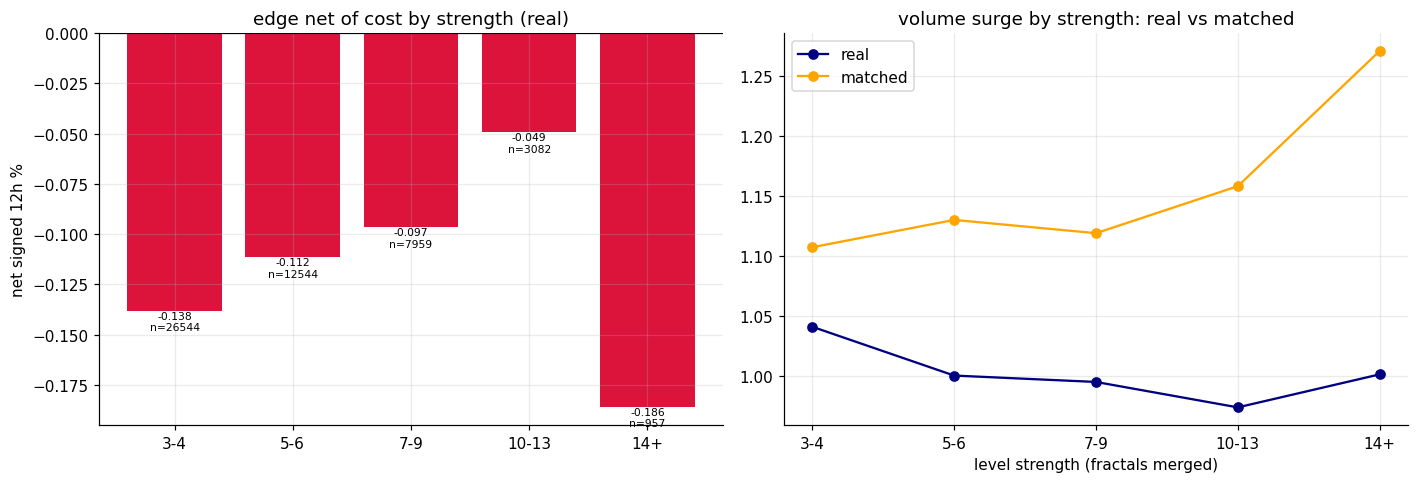

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = range(len(g.index))
ax[0].bar(x, g["net_pct"], color=["crimson" if val<0 else "green" for val in g["net_pct"]])
ax[0].set_xticks(list(x)); ax[0].set_xticklabels(g.index); ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_title("edge net of cost by strength (real)"); ax[0].set_ylabel("net signed 12h %")
for i, val in enumerate(g["net_pct"]): ax[0].text(i, val, f"{val:.3f}\nn={int(g['n'].iloc[i])}", ha="center", fontsize=7, va="bottom" if val>=0 else "top")
ax[1].plot(range(len(gv)), gv["real"], "o-", color="navy", label="real")
ax[1].plot(range(len(gv)), gv["matched"], "o-", color="orange", label="matched")
ax[1].set_xticks(range(len(gv))); ax[1].set_xticklabels(gv.index)
ax[1].set_title("volume surge by strength: real vs matched"); ax[1].set_xlabel("level strength (fractals merged)"); ax[1].legend()
show("08_strength")

## Verdict

- **edge растёт с силой и пробивает издержки у сильнейших** → конфлюэнс фракталов
  ловит реальные уровни; вот рескью. Если плоско/в нуле — сила не помогает.
- **volume: real круто выше matched и расходится с силой** → след внимания, не
  расположение. Если real≈matched на всех бинах → снова конфаунд.